In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import xarray as xr
from netCDF4 import Dataset
import seaborn as sns
import pandas as pd
import pickle
import cartopy.crs as ccrs
import cartopy.feature as cf
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator)
import matplotlib.cm as cm
import dask
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster
from pathlib import Path
from typing import Optional, Dict
import string

import function_en as f

In [2]:
cluster = LocalCluster()
client = Client(cluster) #, n_workers = 6
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 48,Total memory: 187.06 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36369,Workers: 8
Dashboard: http://127.0.0.1:8787/status,Total threads: 48
Started: Just now,Total memory: 187.06 GiB
Comm: tcp://127.0.0.1:39055,Total threads: 6
Dashboard: http://127.0.0.1:43117/status,Memory: 23.38 GiB
Nanny: tcp://127.0.0.1:42379,


In [3]:
basins = {
    "North Atlantic": (0, 70, -90, 10, 'NA'),
    "South Atlantic": (-45, -5, -60, 20, 'SA'),
    "Indian Ocean": (-20, 20, 30, 110, 'IO'),
    "North Pacific": (5, 65, -100, 140, 'NP'),
    "South Pacific": (-65, -5, -80, 160, 'SP'),
    "Southern Ocean": (-70, -20, -180, 179, 'SO'),
    "all": (-90, 90, -180, 179, 'all')
}

In [4]:
def main(latmin, latmax, lonmin, lonmax, basin):
    # Path to the logbook file
    logbook_path = Path('/home/neele.sander/Downloads/Tier4_180326.csv')

    # Load and mask logbook data
    datana = f.load_logbook(logbook_path, lonmin, lonmax, latmin, latmax, basin)
    #need this in the newest version because of renaming
    #datana = datana.rename(columns={"Wind Speed/Force" :"Wind description","Wind Force": "Wind Speed/Force"})
    # Initialize dictionary to store results
    reanalysis: Dict[int, Optional[pd.DataFrame]] = {}

    # Define range of years
    years = range(1824, 1901)

    # Base directory for model data
    base_data_dir = Path('/data0/neele.sander')

    for year in years:
        result = f.process_year(
            year=year,
            datana=datana,
            lon_min=lonmin,
            lon_max=lonmax,
            lat_min=latmin,
            lat_max=latmax,
            data_dir=base_data_dir,
            basin = basin
        )
        reanalysis[year] = result
        print(f'Done processing year {year}')
    data_whaler = datana[datana['year'].isin(years)]    
    alle = pd.concat([reanalysis[year] for year in years])
    return alle.reset_index(), data_whaler
basin = 'Indian Ocean'        
latmin, latmax, lonmin, lonmax = basins[basin][0:4]
if __name__ == "__main__":
    data_model, datana = main(latmin, latmax, lonmin, lonmax, basin)


/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


Done processing year 1824


/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


Done processing year 1825


/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


...

/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


Done processing year 1898


/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


Done processing year 1899
Done processing year 1900


/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/neele.sander/anaconda3/lib/python3.9/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


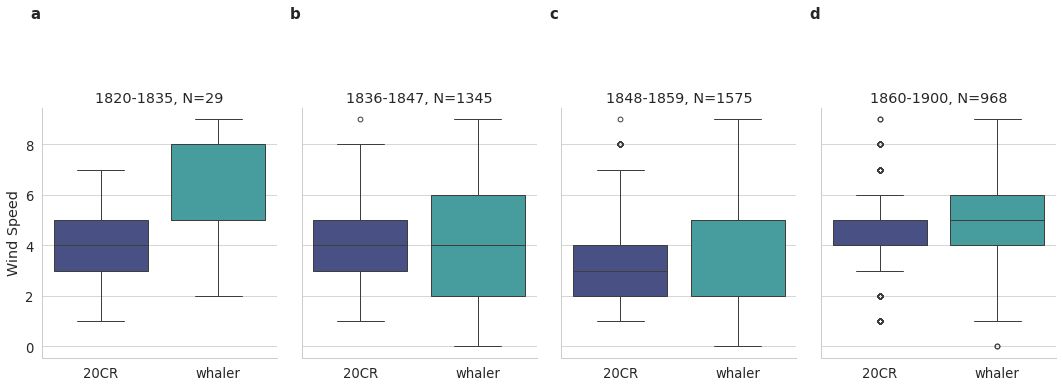

In [5]:
periods = [1820,1836, 1848, 1860, 1901]
data_model['year'] = pd.DatetimeIndex(data_model['time']).year

# Split the data based on periods
period_data = f.split_dyn_periods(data_model, datana, periods)

labels = string.ascii_lowercase
# Plot boxplots for each period dynamically
sns.set(style = 'whitegrid', context = 'paper', font_scale=1.5)
fig, axes = plt.subplots(1, len(periods) - 1, figsize=(15, 6), sharey = True, sharex = True)

# Create a boxplot for each period dynamically
for i, (start, end) in enumerate(zip(periods, periods[1:])):
    period_name = f"period_{i+1}_{start}_{end-1}"
    period_number = f"N_period_{i+1}_{start}_{end-1}"
    N_period = period_data[period_number]
    sns.boxplot(data=period_data[period_name], palette='mako', ax=axes[i])
    axes[i].set_title(f'{start}-{end-1}, N={N_period}')
    axes[i].set_ylabel('Wind Speed' if i == 0 else '')  # Only label the first axis
    axes[i].text(-0.6,13, labels[i],weight= 'bold', fontsize=15)
sns.despine(top = True)
plt.tight_layout()
#plt.savefig('plots/paper/boxplot20CRwhaler.png', dpi = 300, bbox_inches = 'tight') # need to redo for NA
plt.show()


In [6]:
datana = datana[(datana['year'] >= 1820) & (datana['year'] < 1900)]

In [7]:
data_model= data_model[(data_model['year'] >= 1820) & (data_model['year'] < 1900)]

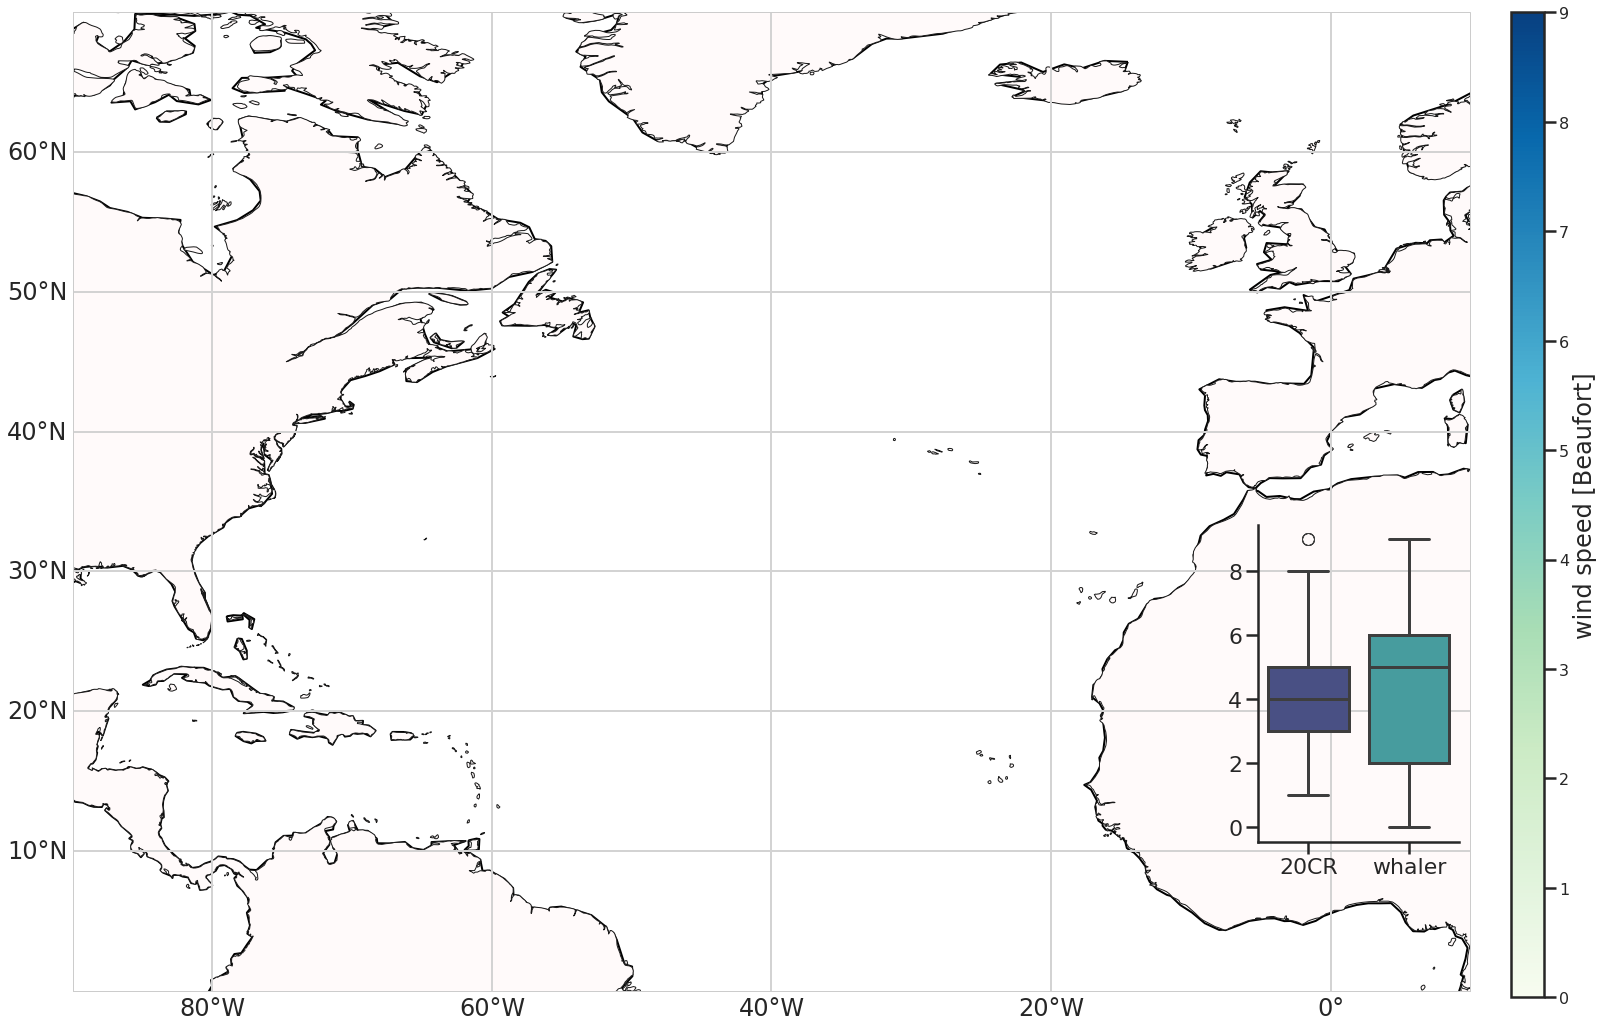

In [8]:
NA_df = pd.DataFrame(data ={'20CR' : data_model['WSPD10m'], 'whaler': datana['Wind Speed/Force']})

fig, ax1 = plt.subplots(1,1, figsize = (30,18), subplot_kw=dict(projection=ccrs.PlateCarree(),
                                                              transform = ccrs.PlateCarree()))
sns.set(style='ticks', context='poster')
sns.scatterplot(data =datana, x ='lon', y = 'lat', hue = 'Wind Speed/Force',ax = ax1, palette = "GnBu",
           alpha = 1)#,transform=ccrs.PlateCarree(),s = 20
ax1.get_legend().remove()
ax1.coastlines()
ax1.set_extent([-90, 10, 0, 70], crs = ccrs.PlateCarree())
ax1.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow', 
                                      edgecolor = 'k', linewidth = 1.0)) ##, facecolor = [.945, .82, .565]

gl = ax1.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False

latpos_NA = 22
lonpos_NA = 10
wrax_NA = inset_axes(ax1,
width=2.8,                             
height=4.4,                            
loc='center right',                        
bbox_to_anchor=(lonpos_NA, latpos_NA), 
bbox_transform=ax1.transData)    
wrax_NA.set_facecolor("none")
sns.boxplot(data = NA_df, palette = 'mako', ax = wrax_NA,linewidth=3)
sns.despine(top=True)

#colorbar
fig.subplots_adjust(right = 0.89)
norm = plt.Normalize(datana['Wind Speed/Force'].min(), datana['Wind Speed/Force'].max())
sm = plt.cm.ScalarMappable(cmap= 'GnBu', norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.85, 0.12, 0.015, 0.76])
cbar = fig.colorbar(sm, cax = cbar_ax, alpha = 1)
for t in cbar.ax.get_yticklabels():
     t.set_fontsize(16)
cbar.set_label('wind speed [Beaufort]')
#plt.savefig('plots/paper/boxplotmap.png', dpi = 300, bbox_inches = 'tight') # need to redo for NA!!!!!

In [9]:
# sort by season to create histogram
def month_to_season(month):
    """
    convert month to season --> MAM, JJA, SON, DJF
    
    Parameters
    ---
    month: month
    
    Returns
    ---
    season
    """
    if 3 <= month <= 5:
        return 'MAM'
    elif 6 <= month <= 8:
        return 'JJA'
    elif 9 <= month <= 11:
        return 'SON'
    else:
        return 'DJF'

def assign_amount_season(data):
    """
    count the amount of logbook entries per season
    
    Parameters
    ---
    data: pandas dataframe of whaling data
    
    Returns
    ---
    pandas dataframe
    """
    N_season = {season: (data['season'] == season).sum() for season in data['season'].unique()}
    data['season'] = data['season'].map(lambda season: f"{season}, N={N_season.get(season, 0)}")
    
    return data

# sort whaling data by season
datana.loc[:, 'season'] = datana['month'].apply(month_to_season)
datana = assign_amount_season(datana)
#sort model data by season
data_model['month'] = data_model['time'].dt.month
data_model.loc[:, 'season'] = data_model['month'].apply(month_to_season)
#Concatenate data based on season
data_model = data_model.reset_index().rename(columns={'index': 'original_index'})

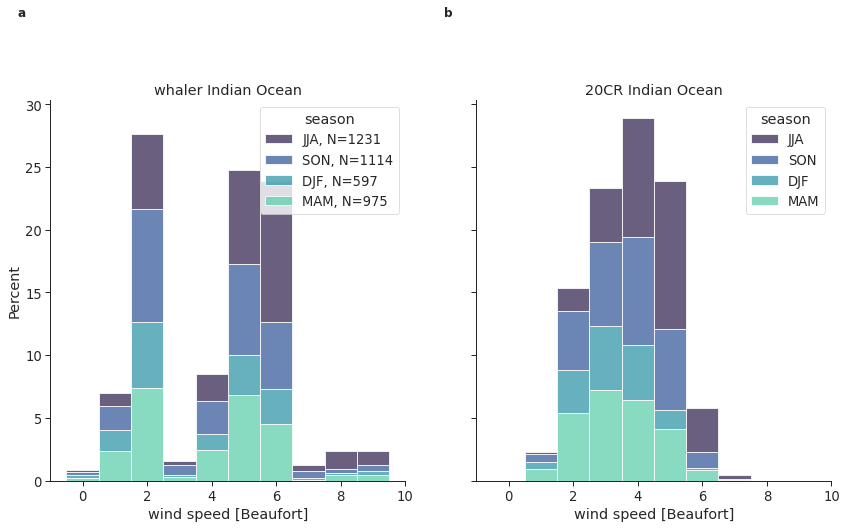

In [10]:
# create seasonal ensemble plot
sns.set(style = 'ticks', context = 'paper', font_scale=1.5) 
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (14,7), sharex = True, sharey = True)
sns.histplot(data = datana, x = 'Wind Speed/Force',stat='percent',multiple = 'stack', hue = 'season',
             ax = ax1, discrete = True, palette = 'mako')
sns.histplot(data =data_model, x = 'WSPD10m',stat='percent',multiple = 'stack', hue = 'season',
             ax = ax2, discrete = True, palette = 'mako')#, hue_order = ['JJA', 'SON', 'DJF', 'MAM'])
sns.despine(top = True)
ax1.set(xlabel = 'wind speed [Beaufort]',title = 'whaler ' + basin)
ax1.text(-2,37, 'a', weight = 'bold', size = 12)
ax2.set(xlabel = 'wind speed [Beaufort]',title = '20CR '+ basin)
ax2.text(-2,37, 'b', weight = 'bold', size = 12)
#plt.savefig('plots/paper/histNAwhaler_20CRindvensemble_season.png', dpi = 300, bbox_inches = 'tight') # need to redo for NA!!!
plt.show()

In [14]:
# safe dataset for North Atlantic, try with other basins
#data_model.to_csv('/data0/neele.sander/corr_indv_ens_20cr_IO_19-03-26.csv')

In [15]:
#datana.to_csv('/data0/neele.sander/whaler_IO_19-03-26.csv')

In [13]:
#stop

NameError: name 'stop' is not defined

In [6]:
# now open all the datasets to put them in one map
paths_whaler = ['/data0/neele.sander/whaler_NA_19-03-26.csv',
                '/data0/neele.sander/whaler_SA_19-03-26.csv',
               '/data0/neele.sander/whaler_NP_19-03-26.csv',
               '/data0/neele.sander/whaler_SP_19-03-26.csv',
               '/data0/neele.sander/whaler_IO_19-03-26.csv']

paths_model = ['/data0/neele.sander/corr_indv_ens_20cr_NA_19-03-26.csv',
              '/data0/neele.sander/corr_indv_ens_20cr_SA_19-03-26.csv',
              '/data0/neele.sander/corr_indv_ens_20cr_NP_19-03-26.csv',
              '/data0/neele.sander/corr_indv_ens_20cr_SP_19-03-26.csv',
              '/data0/neele.sander/corr_indv_ens_20cr_IO_19-03-26.csv']
data_whaler_NA = pd.read_csv(paths_whaler[0], engine='python')
data_whaler_SA = pd.read_csv(paths_whaler[1], engine='python')
data_whaler_NP = pd.read_csv(paths_whaler[2], engine='python')
data_whaler_SP = pd.read_csv(paths_whaler[3], engine='python')
data_whaler_IO = pd.read_csv(paths_whaler[4], engine='python')

north_atlantic_20CR = pd.read_csv(paths_model[0])
south_atlantic_20CR = pd.read_csv(paths_model[1])
north_pacific_20CR = pd.read_csv(paths_model[2])
south_pacific_20CR = pd.read_csv(paths_model[3])
indian_ocean_20CR = pd.read_csv(paths_model[4])

# only between 1820 and 1900
data_whaler_NA = data_whaler_NA[(data_whaler_NA['year'] >= 1820) & (data_whaler_NA['year'] < 1900)]
data_whaler_SA = data_whaler_SA[(data_whaler_SA['year'] >= 1820) & (data_whaler_SA['year'] < 1900)]
data_whaler_NP = data_whaler_NP[(data_whaler_NP['year'] >= 1820) & (data_whaler_NP['year'] < 1900)]
data_whaler_SP = data_whaler_SP[(data_whaler_SP['year'] >= 1820) & (data_whaler_SP['year'] < 1900)]
data_whaler_IO = data_whaler_IO[(data_whaler_IO['year'] >= 1820) & (data_whaler_IO['year'] < 1900)]

north_atlantic_20CR = north_atlantic_20CR[(north_atlantic_20CR['year'] >= 1820) & (north_atlantic_20CR['year'] < 1900)]
south_atlantic_20CR = south_atlantic_20CR[(south_atlantic_20CR['year'] >= 1820) & (south_atlantic_20CR['year'] < 1900)]
north_pacific_20CR = north_pacific_20CR[(north_pacific_20CR['year'] >= 1820) & (north_pacific_20CR['year'] < 1900)]
south_pacific_20CR = south_pacific_20CR[(south_pacific_20CR['year'] >= 1820) & (south_pacific_20CR['year'] < 1900)]
indian_ocean_20CR = indian_ocean_20CR[(indian_ocean_20CR['year'] >= 1820) & (indian_ocean_20CR['year'] < 1900)]

In [7]:
NA_df = pd.DataFrame(data ={'20CR' : north_atlantic_20CR['WSPD10m'], 'whaler': data_whaler_NA['Wind Speed/Force']})
SA_df = pd.DataFrame(data ={'20CR' : south_atlantic_20CR['WSPD10m'], 'whaler': data_whaler_SA['Wind Speed/Force']})
IO_df = pd.DataFrame(data ={'20CR' : indian_ocean_20CR['WSPD10m'], 'whaler': data_whaler_IO['Wind Speed/Force']})
NP_df = pd.DataFrame(data ={'20CR' : north_pacific_20CR['WSPD10m'], 'whaler': data_whaler_NP['Wind Speed/Force']})
SP_df = pd.DataFrame(data ={'20CR' : south_pacific_20CR['WSPD10m'], 'whaler': data_whaler_SP['Wind Speed/Force']})

In [8]:
logbook_path = Path('/home/neele.sander/Downloads/Tier4.csv')
basin = 'all'
latmin, latmax, lonmin, lonmax, basin = basins['all']
# Load and mask logbook data
datana = f.load_logbook(logbook_path, lonmin, lonmax, latmin, latmax, basin)
datana = datana[(datana['year'] >= 1820) & (datana['year'] < 1900)]

/tmp/ipykernel_41900/3646714327.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_NA.set_xticklabels([None, None])
/tmp/ipykernel_41900/3646714327.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_SA.set_xticklabels([None, None])
/tmp/ipykernel_41900/3646714327.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_NP.set_xticklabels([None, None])
/tmp/ipykernel_41900/3646714327.py:76: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_SP.set_xticklabels([None, None])
/tmp/ipykernel_41900/3646714327.py:89: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_IO.set_xticklabels([None, None])


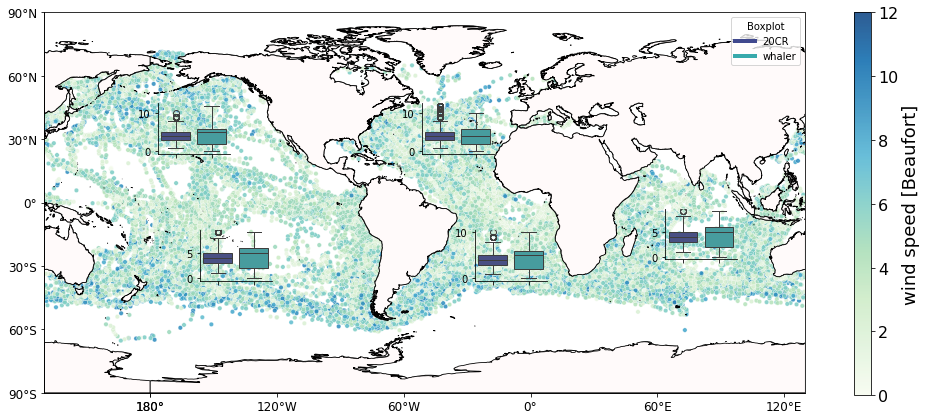

In [9]:
cm = 310
proj = ccrs.PlateCarree(central_longitude=cm)
fig, ax1 = plt.subplots(1,1, figsize = (16,7), subplot_kw=dict(projection=proj,transform = ccrs.PlateCarree())) #
#sns.set(style='ticks', context='paper')
# ax1.grid()
sns.scatterplot(x = datana['lon']+360-cm, y = datana['lat'], hue = datana['Wind Speed/Force'],
                s = 20,ax = ax1, palette = "GnBu", alpha = 0.85) 
ax1.get_legend().remove()
ax1.coastlines()
ax1.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow', 
                                      edgecolor = 'k', linewidth = 0.8))

#gl = ax1.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = False)
ax1.set(ylabel = None, xlabel = None)
ax1.set_xticks([-180, -120, -60,0, 60, 120, 180], crs=ccrs.PlateCarree())
ax1.set_yticks([-90, -60, -30, 0, 30, 60, 90], crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(zero_direction_label=False)
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
ax1.tick_params(axis='both', which='major', labelsize=12)


#NA
latpos_NA = 35
lonpos_NA = -15 +360-cm
wrax_NA = inset_axes(ax1,
width=1,                             
height=0.7,                           
loc='center right',                   
bbox_to_anchor=(lonpos_NA, latpos_NA),
bbox_transform=ax1.transData)    
wrax_NA.set_facecolor("none")
sns.boxplot(data = NA_df, palette = 'mako', ax = wrax_NA)
sns.despine(top=True)
wrax_NA.set_xticklabels([None, None])
#SA
latpos_SA = -25
lonpos_SA = 10+360-cm
wrax_SA = inset_axes(ax1,
width=1,                          
height=0.7,                       
loc='center right',               
bbox_to_anchor=(lonpos_SA, latpos_SA), 
bbox_transform=ax1.transData)    
wrax_SA.set_facecolor("none")
sns.boxplot(data = SA_df, palette = 'mako', ax = wrax_SA)
sns.despine(top=True)
wrax_SA.set_xticklabels([None, None])
#NP
latpos_NP = 35
lonpos_NP = -140+360-cm
wrax_NP = inset_axes(ax1,
width=1,                             
height=0.7,                          
loc='center right',                  
bbox_to_anchor=(lonpos_NP, latpos_NP),
bbox_transform=ax1.transData)    
wrax_NP.set_facecolor("none")
sns.boxplot(data = NP_df, palette = 'mako', ax = wrax_NP)
sns.despine(top=True)
wrax_NP.set_xticklabels([None, None])
#SP
latpos_SP = -25
lonpos_SP = -120+360-cm
wrax_SP = inset_axes(ax1,
width=1,                             
height=0.7,                          
loc='center right',                  
bbox_to_anchor=(lonpos_SP, latpos_SP), 
bbox_transform=ax1.transData)    
wrax_SP.set_facecolor("none")
sns.boxplot(data = SP_df, palette = 'mako',ax = wrax_SP)
sns.despine(top=True)
wrax_SP.set_xticklabels([None, None])
#IO
latpos_IO = -15
lonpos_IO = 100+360-cm
wrax_IO = inset_axes(ax1,
width=1,                            
height=0.7,                         
loc='center right',                       
bbox_to_anchor=(lonpos_IO, latpos_IO), 
bbox_transform=ax1.transData)    
wrax_IO.set_facecolor("none")
sns.boxplot(data = IO_df, palette = 'mako', ax = wrax_IO)
sns.despine(top=True)
wrax_IO.set_xticklabels([None, None])

#legend
#ax1.legend(NA_df.columns, loc="upper right")
from matplotlib.lines import Line2D
palette = sns.color_palette("mako", n_colors=NA_df.shape[1])
handles = [Line2D([0], [0], color=palette[i], lw=4, label=col) 
           for i, col in enumerate(NA_df.columns)]

ax1.legend(handles=handles, title="Boxplot", loc="upper right")

#colorbar
fig.subplots_adjust(right = 0.83)
norm = plt.Normalize(datana['Wind Speed/Force'].min(), datana['Wind Speed/Force'].max())
sm = plt.cm.ScalarMappable(cmap= 'GnBu', norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.85, 0.12, 0.015, 0.76])
cbar = fig.colorbar(sm, cax = cbar_ax, alpha = 0.85)
for t in cbar.ax.get_yticklabels():
     t.set_fontsize(16)
cbar.set_label('wind speed [Beaufort]', size = 18)
plt.savefig('plots/paper/Boxplotmap_indv_ens.png', dpi = 300, bbox_inches = 'tight')